In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [27]:
df = pd.read_csv("../data/raw/churn-bigml-80.csv")

df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [28]:
df.shape

(2666, 20)

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   str    
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   str    
 4   Voice mail plan         2666 non-null   str    
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   float64
 15

In [30]:
df.isnull().sum()

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

In [31]:
df['Churn'].value_counts(normalize=True)

Churn
False    0.854464
True     0.145536
Name: proportion, dtype: float64

In [32]:
df['International plan'] = df['International plan'].map({'Yes': 1, 'No': 0})

In [33]:
df['Voice mail plan'] = df['Voice mail plan'].map({'yes': 1, 'no': 0})

In [34]:
df['Churn'] = df['Churn'].astype(int)

In [35]:
print(df[['International plan', 'Voice mail plan', 'Churn']].dtypes)

International plan      int64
Voice mail plan       float64
Churn                   int64
dtype: object


In [36]:
# Checking if Minutes and Charge are essentially the same thing
correlation_pairs = [
    ['Total day minutes', 'Total day charge'],
    ['Total eve minutes', 'Total eve charge'],
    ['Total night minutes', 'Total night charge']
]

for pair in correlation_pairs:
    print(f"Correlation for {pair}: {df[pair].corr().iloc[0,1]:.4f}")

Correlation for ['Total day minutes', 'Total day charge']: 1.0000
Correlation for ['Total eve minutes', 'Total eve charge']: 1.0000
Correlation for ['Total night minutes', 'Total night charge']: 1.0000


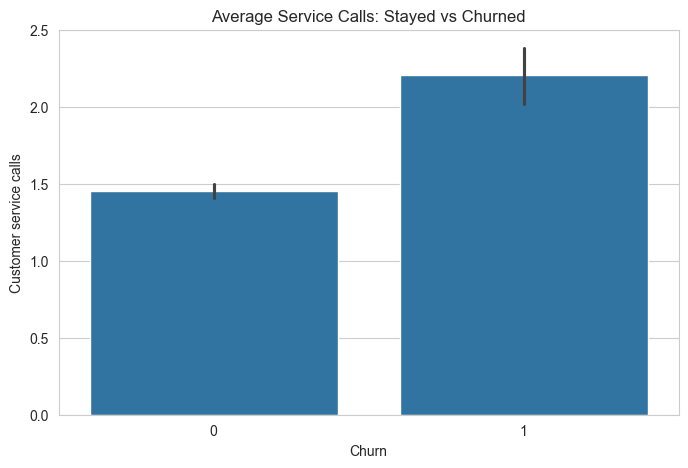

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Churn', y='Customer service calls', data=df)
plt.title('Average Service Calls: Stayed vs Churned')
plt.show()

In [38]:
# Drop redundant charge columns
cols_to_drop = ['Total day charge', 'Total eve charge', 'Total night charge', 'Total intl charge']
df.drop(columns=cols_to_drop, inplace=True)

# Verify
print(f"New shape: {df.shape}")
print(df.columns)

New shape: (2666, 16)
Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total eve minutes', 'Total eve calls',
       'Total night minutes', 'Total night calls', 'Total intl minutes',
       'Total intl calls', 'Customer service calls', 'Churn'],
      dtype='str')


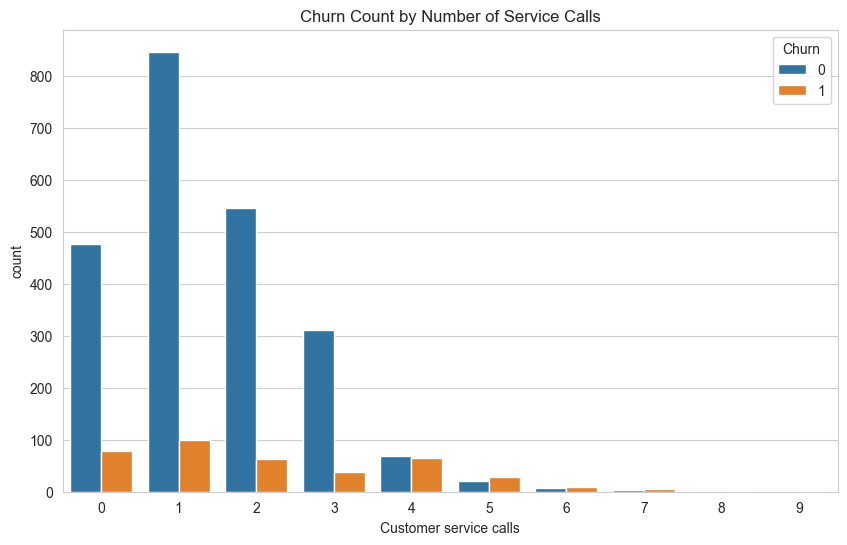

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.countplot(x='Customer service calls', hue='Churn', data=df)
plt.title('Churn Count by Number of Service Calls')
plt.show()

### Key Insight: The "Customer Service Call" Tipping Point
The distribution of churn reveals a clear **"Danger Zone"** starting at 4 service calls:

* **Safe Zone (0-3 calls):** High customer retention. The majority of the user base falls here, and churn is relatively low.
* **The Critical Threshold (4 calls):** This is the pivot point. The probability of churn increases dramatically to roughly **50%**.
* **The Exit Zone (5+ calls):** The "Churn" bars surpass the "Stayed" bars. At this stage, a customer is statistically more likely to leave than stay.

**Recommendation:** Business logic should trigger a "Retention Offer" or escalate to a senior representative once a customer reaches their **3rd or 4th call**.

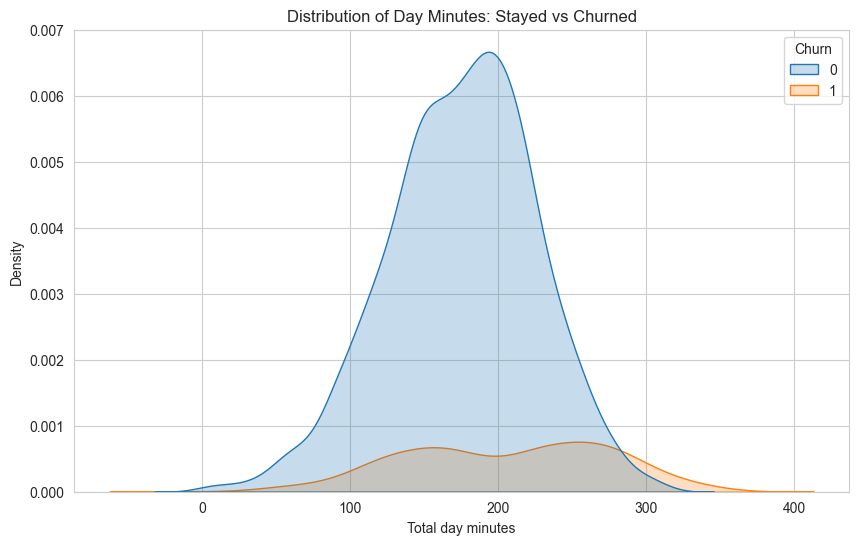

In [40]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='Total day minutes', hue='Churn', fill=True)
plt.title('Distribution of Day Minutes: Stayed vs Churned')
plt.show()

## 📊 Key Insight: High Usage and the "Heavy User" Churn

The density plot for **Total Day Minutes** reveals a significant behavioral difference between loyal and churning customers:

* **The Loyal Peak:** Customers who stay are concentrated in the **150–250 minute** range.
* **The High-Usage Gap:** There is a distinct "bump" in churned customers (orange) who exceed **300 minutes** per day. 
* **Takeaway:** High-usage customers are significantly more likely to churn. Given that minutes and charges are perfectly correlated ($1.0$), these users are likely facing high monthly bills, making them sensitive to competitor pricing or "Unlimited" plan offers.

**Recommendation:** The marketing team should target customers exceeding 250 minutes with "High-Volume" or "Unlimited" talk bundles to prevent them from switching to competitors with better heavy-usage rates.

In [41]:
print(df.columns)

Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total eve minutes', 'Total eve calls',
       'Total night minutes', 'Total night calls', 'Total intl minutes',
       'Total intl calls', 'Customer service calls', 'Churn'],
      dtype='str')



Churn Rate Percentages:
Churn                       0          1
International plan                      
0                   88.731219  11.268781
1                   56.296296  43.703704


C:\Users\Acer\AppData\Local\Temp\ipykernel_508\186951843.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='International plan', y='Churn', data=df, palette='viridis')


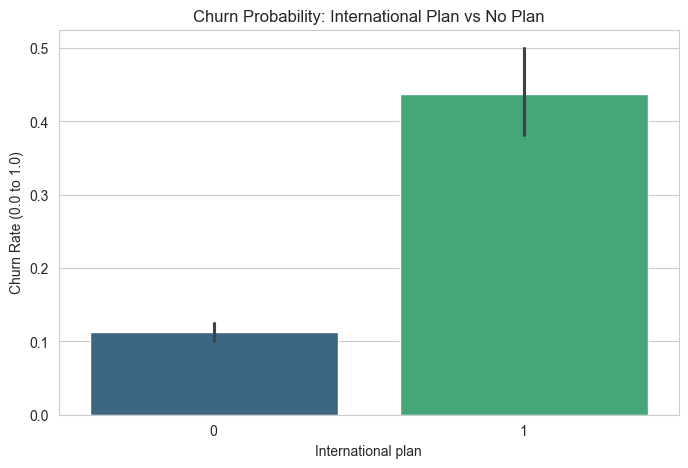

In [49]:
intl_churn_stats = df.groupby('International plan')['Churn'].value_counts(normalize=True).unstack()
print("\nChurn Rate Percentages:")
print(intl_churn_stats * 100)

plt.figure(figsize=(8, 5))
sns.barplot(x='International plan', y='Churn', data=df, palette='viridis')
plt.title('Churn Probability: International Plan vs No Plan')
plt.ylabel('Churn Rate (0.0 to 1.0)')
plt.show()

# The Insight: International Plans are a "Churn Magnet"

- **No International Plan (0):** Churn rate is only ~11.3%.
- **With International Plan (1):** Churn rate skyrockets to ~43.7%.

Customers with the international plan are nearly **4 times more likely to leave** than those without it. This is a massive **"red flag"** in the data—usually suggesting that the international plan is either too expensive, has poor connection quality, or competitors are offering a much better deal.

In [50]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Final Feature Correlation Heatmap')
plt.show()

ValueError: could not convert string to float: 'KS'

<Figure size 1200x800 with 0 Axes>

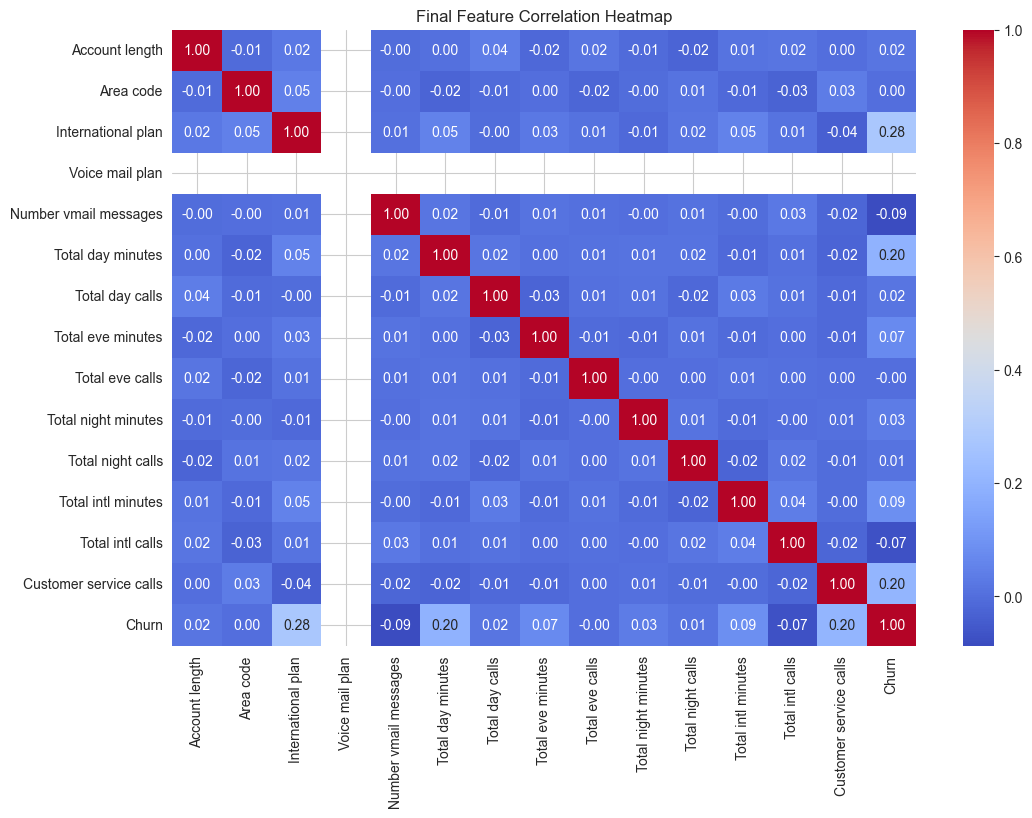

In [51]:
plt.figure(figsize=(12,8))
# Add numeric_only=True inside the corr() function
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Final Feature Correlation Heatmap')
plt.show()

# 📊 Feature Correlation Highlights

The heatmap shows key drivers of **Churn** in a glance.

| Feature | Correlation with Churn | Insight |
|---------|----------------------|---------|
| 🌐 International Plan | 0.28 | Strongest churn indicator; plan may be uncompetitive |
| 📞 Customer Service Calls | 0.20 | Frequent support calls signal dissatisfaction |
| ⏱ Total Day Minutes | 0.20 | Heavy daytime users slightly more likely to leave |
| ☎ Total Day Calls | 0.01 | Call count has minimal impact; duration matters more |
| ✈ Total Intl Minutes | 0.05 | Low impact compared to having the plan itself |

**Quick Takeaways:**
- 🚨 **Proactive Outreach:** Target frequent support callers  
- 💡 **Plan Review:** Improve International Plan value  
- 🎯 **Retention:** Reward high-usage customers with loyalty programs or tailored plans